In [116]:
from pathlib import Path
import pandas as pd


data_folder = Path(".").resolve().parent / "data"

m = pd.read_parquet(data_folder / "math.parquet", columns=["problem", "solution", "level"])
m = m.reset_index(names="question_id")
m["question_id"] = m["question_id"].astype("string")

a = pd.read_parquet(data_folder / "aime.parquet", columns=["ID", "Question", "Answer"])
a = a.rename(columns={"ID": "question_id", "Question": "problem", "Answer": "solution"})
a["level"] = "6"

q = pd.concat((m, a), ignore_index=True)
q = q.drop_duplicates("question_id")
q["level"] = q["level"].str.replace("Level", "").str.strip()
q["level"] = pd.to_numeric(q["level"], errors="coerce")

In [119]:
a.iloc[659,]

question_id                                            2015-I-10
problem        Let $f(x)$ be a third-degree polynomial with r...
solution                                                      72
level                                                          6
Name: 659, dtype: object

In [3]:
q["level"].value_counts(dropna=False)

level
5.0    3628
4.0    2904
3.0    2723
2.0    2242
1.0    1001
6.0     933
NaN       2
Name: count, dtype: int64

In [42]:
df = pd.read_csv("../data/results.csv", header=None)
df.columns = ["question_id", "level", "actual_tokens", "is_correct", "method"]
df

,question_id,level,actual_tokens,is_correct,method
0,3321,Level 5,4051,False,base
1,4155,Level 5,4332,True,base
2,2682,Level 5,2923,True,base
3,2810,Level 5,3443,True,base
4,2120,Level 5,6079,False,base
...,...,...,...,...,...
355,2010-II-4,aimee,3713,True,dpo
356,2010-II-12,aimee,4996,True,dpo
357,2011-I-10,aimee,6072,False,dpo
358,2012-I-11,aimee,6185,False,dpo


In [107]:
def load_batches(folder: Path) -> pd.DataFrame:

    dfs = []
    for batch_file in folder.glob("*.parquet"):
        
        dfs.append(pd.read_parquet(batch_file))

    if len(dfs) == 0:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

def add_levels_and_solution(df: pd.DataFrame) -> pd.DataFrame:

    data_folder = Path(".").resolve().parent / "data"

    m = pd.read_parquet(data_folder / "math.parquet", columns=["problem", "solution", "level"])
    m = m.reset_index(names="question_id")
    m["question_id"] = m["question_id"].astype("string")

    a = pd.read_parquet(data_folder / "aime.parquet", columns=["ID", "Question", "Answer"])
    a = a.rename(columns={"ID": "question_id", "Question": "problem", "Answer": "solution"})
    a["level"] = "6"

    q = pd.concat((m, a), ignore_index=True)
    q = q.drop_duplicates("question_id")
    q["level"] = q["level"].str.replace("Level", "").str.strip()
    q["level"] = pd.to_numeric(q["level"], errors="coerce")

    df = pd.merge(df, q[["question_id", "level", "solution"]], "left", "question_id", validate="m:1")
    return df


df = load_batches(Path(".").resolve().parent / "dynamic_regressor_results")
df = add_levels_and_solution(df).drop(columns="solution")


In [64]:
df.sample(1)

,question_id,step_i,problem,expected_solution,target_tokens,actual_tokens,is_correct,generated_text,bin_100,bin_1166,bin_1433,bin_1700,bin_1966,bin_2233,bin_2500,bin_366,bin_633,bin_900,level
245,2444,61,"How many integers from 1 through 9999, inclusi...","We have 6 digits to choose from: 0, 1, 6, 7, 8...",1433,3100,None,,0.000412,0.068834,1.0,0.999851,0.00013,0.000228,0.999999,0.001507,0.999567,0.331176,5.0


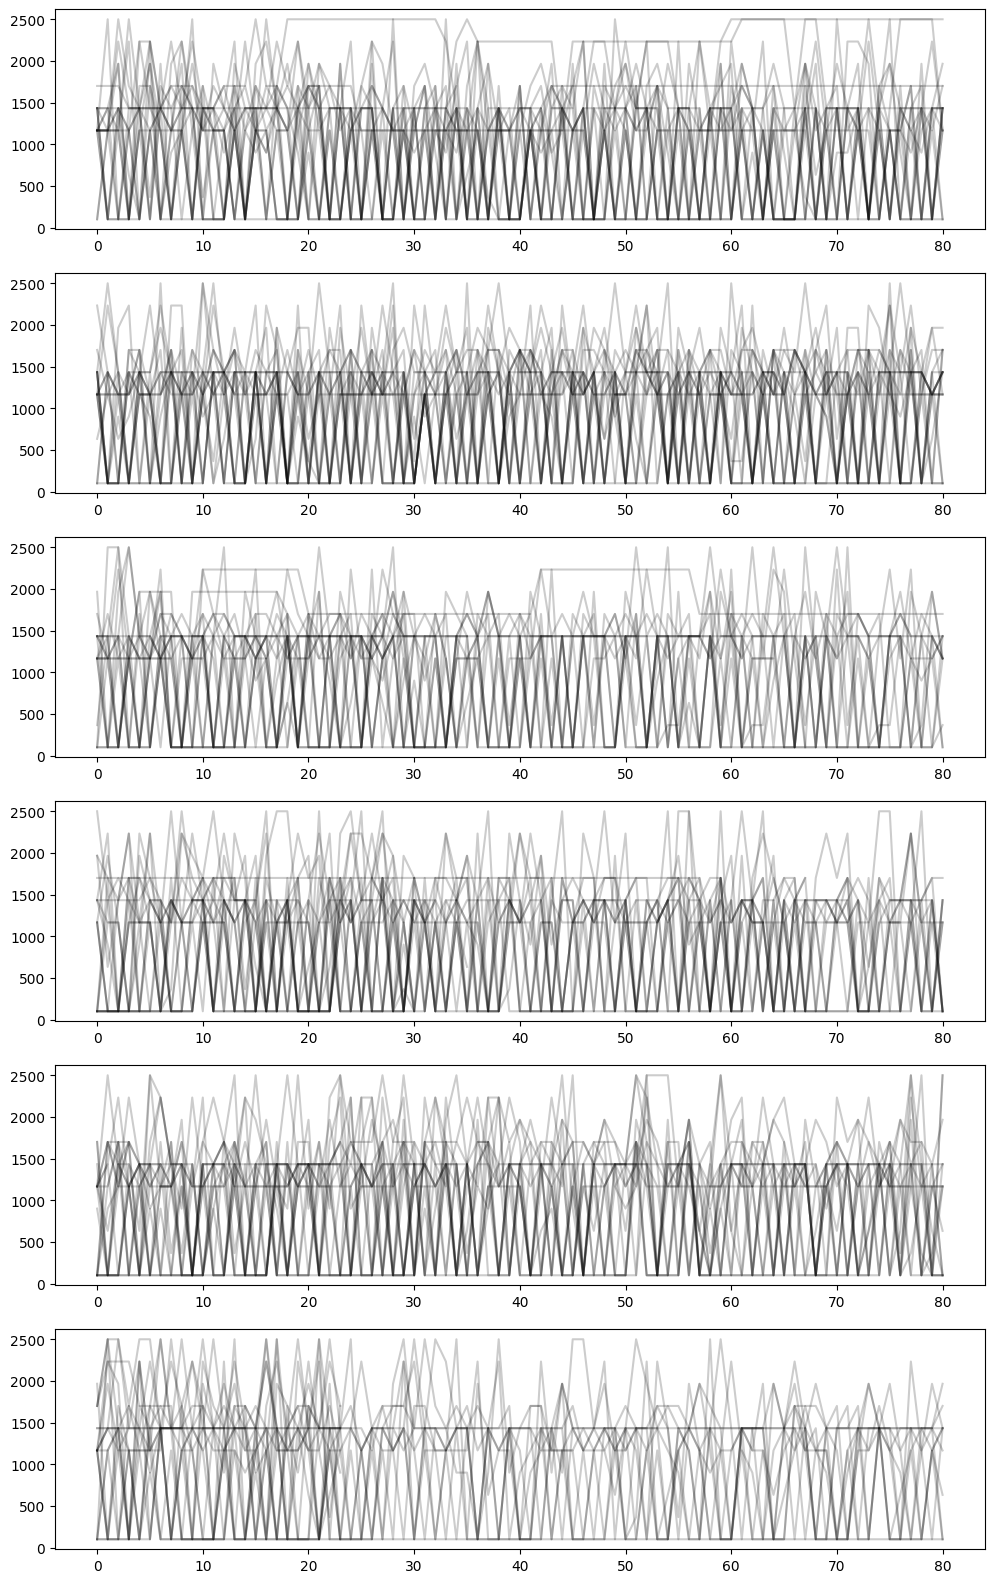

In [87]:
from matplotlib import pyplot as plt
import numpy as np


df = df.sort_values(["question_id", "step_i"])
df["level"] = df["level"].astype(int)

assert not df.duplicated(["question_id", "step_i"]).any()

wide = pd.pivot(df, index=["question_id", "level"], columns="step_i", values="target_tokens")
steps = pd.to_numeric(wide.columns, errors="raise")

wide.reset_index(level=1)

fig, axs = plt.subplots(6, 1, figsize=(12, 20))

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]

for i_level, (level, l_wide) in enumerate(wide.groupby("level")):

    ax = axs[i_level]

    for i in range(l_wide.shape[0]):
        traj = l_wide.iloc[i, :].to_numpy().astype(float)
    

        ax.plot(traj, color="black", alpha=0.2)


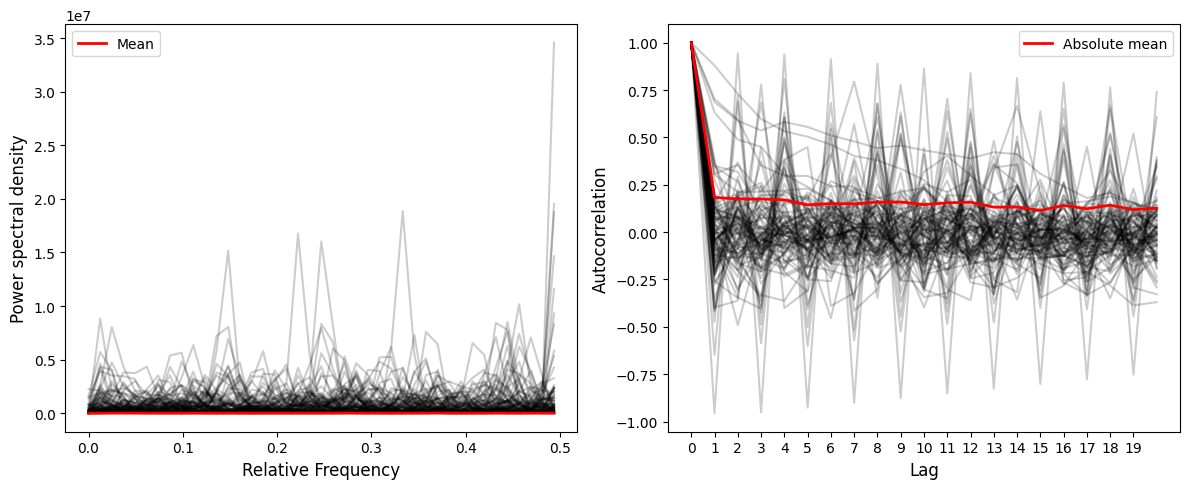

In [121]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from statsmodels.tsa.stattools import acf

X = wide.to_numpy().astype(float)  # shape: (n_trajectories, n_steps)
n_traj, n_steps = X.shape

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for traj in X:
    f, Pxx = welch(traj, nperseg=len(traj))
    ax[0].plot(f, Pxx, color='black', alpha=0.2)

mean_f, mean_Pxx = welch(np.nanmean(X, axis=0), nperseg=n_steps)
ax[0].plot(mean_f, mean_Pxx, color='red', lw=2, label="Mean")
ax[0].set_xlabel("Relative Frequency", fontsize=12)
ax[0].set_ylabel("Power spectral density", fontsize=12)
ax[0].legend()


max_lag = min(20, n_steps - 1)
for traj in X:
    ac = acf(traj, nlags=max_lag, fft=True)
    ax[1].plot(range(max_lag + 1), ac, color='black', alpha=0.2)    

mean_ac = np.nanmean(np.abs([acf(traj, nlags=max_lag, fft=True) for traj in X]), axis=0)
ax[1].plot(range(max_lag + 1), mean_ac, color='red', lw=2, label="Absolute mean")
ax[1].set_xlabel("Lag", fontsize=12)
ax[1].set_ylabel("Autocorrelation", fontsize=12)
ax[1].legend()
ax[1].set_xticks(np.arange(max_lag), np.arange(max_lag))

plt.tight_layout()
plt.show()

fig.savefig("../trajectories.pdf")


In [4]:
import pandas as pd


df = pd.read_parquet("../static_temp.parquet")
df = pd.merge(df, q[["question_id", "level", "solution"]], "left", "question_id", validate="1:1")



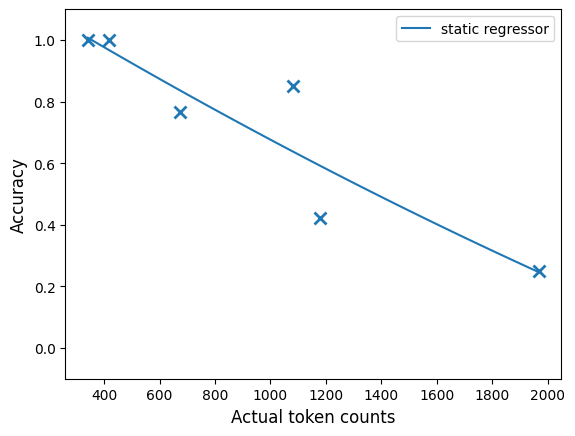

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.patheffects as pe

# Compute your means
tc = df.groupby("level")["actual_tokens"].mean().sort_index()
acc = df.groupby("level")["is_correct"].mean().sort_index()
assert (tc.index == acc.index).all()

fig, ax = plt.subplots()
ax.set_ylim([-0.1, 1.1])

# Plot text markers (numbers as labels) with marker below
for level, x, y in zip(tc.index, tc, acc):
    # Plot marker below text
    ax.plot(x, y, marker='x', color='tab:blue', markersize=8, markeredgewidth=2)

    # Add text with black outline
    # ax.text(
    #     x, y, str(int(level)),
    #     color='tab:blue', fontsize=12, fontweight='bold',
    #     ha='center', va='center',
    #     path_effects=[pe.withStroke(linewidth=5, foreground="black")]
    # )

coeffs = np.polyfit(tc.astype(float).to_numpy(), acc.astype(float).to_numpy(), deg=2)
poly = np.poly1d(coeffs)

x_fit = np.linspace(tc.min(), tc.max(), 100)
y_fit = poly(x_fit)
ax.plot(x_fit, y_fit, color='tab:blue', label="static regressor")

ax.set_xlabel("Actual token counts", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)

ax.legend()

plt.show()


In [36]:
df[df["level"] < 6]["actual_tokens"].mean(), df[df["level"] < 6]["is_correct"].mean()

(np.float64(738.35), np.float64(0.8043478260869565))

In [7]:


def evaluate_answer(expected_answer, generated_answer):
    gen_val = extract_boxed(generated_answer)
    if gen_val is None:
        return False

    exp_val = extract_boxed(expected_answer)
    if exp_val is None:
        exp_val = str(expected_answer).strip()

    return is_equiv(gen_val, exp_val)

for i in df.index[df["level"] == 6.0]:

    prev = df.loc[i, "is_correct"]
    af = evaluate_answer(df.loc[i, "solution"], df.loc[i, "generated_text"])

    if af != prev:
        print(df.loc[i, "question_id"])
        df.loc[i, "is_correct"] = af
        


In [33]:
df["is_correct"].value_counts(normalize=True)

is_correct
True     0.660714
False    0.339286
Name: proportion, dtype: float64

In [ ]:

import numpy as np

df = df.sort_values(["question_id", "step_i"])
ignore_cols = ["step_i", "problem", "expected_solution"]

out = []

for qid, qdf in df.groupby("question_id"):

    correct = qdf["is_correct"].unique()
    correct = [c for c in correct if (c is not None)]

    assert len(correct) < 2, correct

    # Did not answer within limits
    if len(correct) == 0:
        row = qdf.iloc[-1, :]
    else:
        (inds,) = np.where(qdf["is_correct"] == correct[0])
        i = inds.min()
        row = qdf.iloc[i, :]

    row = row.drop(ignore_cols)
    out.append(row.to_dict())


out = pd.DataFrame(out)
out


    
    

,question_id,target_tokens,actual_tokens,is_correct,generated_text,bin_100,bin_366,bin_633,bin_900,bin_1166,bin_1433,bin_1700,bin_1966,bin_2233,bin_2500
0,1013,100,4050,None,,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,2108,100,180,False,Given that\n$\frac 1{2!17!}+\frac 1{3!16!}+\fr...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
df["is_correct"]

0       True
2       True
4       True
6       True
8       True
       ...  
153    False
155    False
157    False
159    False
161    False
Name: is_correct, Length: 162, dtype: bool

In [76]:
# df = pd.read_parquet("../dynamic_regressor_results/batch_1.parquet")

# one = df[df["question_id"] == df["question_id"].sample(1).values[0]]
# one = one.drop(columns="expected_solution")

# with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
#     display(one.sort_values("step_i"))

In [54]:
df = pd.read_parquet("../static_regressor_results/batch_1.parquet")
df

,question_id,problem,expected_solution,target_tokens,actual_tokens,is_correct,generated_text,bin_100,bin_366,bin_633,bin_900,bin_1166,bin_1433,bin_1700,bin_1966,bin_2233,bin_2500
0,9020,Determine the number of ways to arrange the le...,First we count the arrangements if the three E...,100,282,True,<｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of...,0.991116,0.997639,0.999364,0.996697,0.992203,0.996167,0.969323,0.992358,0.999215,0.998021
1,9054,A singles tournament had six players. Each pla...,"Each of the six players played 5 games, and ea...",100,216,True,<｜begin▁of▁sentence｜>A singles tournament had ...,0.965163,0.985205,0.998298,0.997297,0.994144,0.997904,0.997813,0.996939,0.998123,0.996414


In [130]:
import pandas as pd
df2 = pd.read_parquet("../data/test.parquet", columns=['question_id', 'target_think_tokens', 'generated_think_tokens', 'is_correct', 'level'])
df = pd.read_parquet("../data/train.parquet", columns=['question_id', 'target_think_tokens', 'generated_think_tokens', 'is_correct', 'level'])

# df = pd.concat([df, df2], ignore_index=True)
df= df.drop_duplicates("question_id")
df.shape[0]

4369

In [126]:
4489 - 660

3829

In [125]:
df["level"].value_counts()

level
Level 4    1154
Level 3    1068
Level 5    1050
aimee       660
Level 2     365
Level 1     192
Name: count, dtype: int64

In [110]:
df.drop_duplicates("question_id").shape
df["level"].value_counts(normalize=True)

level
Level 5    0.166667
Level 2    0.166667
Level 1    0.166667
Level 3    0.166667
Level 4    0.166667
aimee      0.166667
Name: proportion, dtype: float64

,ID,Year,Problem Number,Question,Answer,Part
0,1983-1,1983,1,"Let $x$ , $y$ and $z$ all exceed $1$ and let $...",60,None
1,1983-2,1983,2,"Let $f(x)=|x-p|+|x-15|+|x-p-15|$ , where $0 < ...",15,None
2,1983-3,1983,3,What is the product of the real roots of the e...,20,None
3,1983-4,1983,4,A machine-shop cutting tool has the shape of a...,26,None
4,1983-5,1983,5,Suppose that the sum of the squares of two com...,4,None
...,...,...,...,...,...,...
928,2024-II-11,2024,11,Find the number of triples of nonnegative inte...,601,II
929,2024-II-12,2024,12,"Let $O(0,0),A(\tfrac{1}{2},0),$ and $B(0,\tfra...",23,II
930,2024-II-13,2024,13,Let $\omega\neq 1$ be a 13th root of unity. Fi...,321,II
931,2024-II-14,2024,14,Let $b \geq 2$ be an integer. Call a positive ...,211,II


,problem,level,type,solution
0,"Let \[f(x) = \left\{\n\begin{array}{cl} ax+3, ...",Level 5,Algebra,"For the piecewise function to be continuous, t..."
1,A rectangular band formation is a formation wi...,Level 5,Algebra,Let $x$ be the number of band members in each ...
2,What is the degree of the polynomial $(4 +5x^3...,Level 3,Algebra,This polynomial is not written in standard for...
3,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,Level 3,Algebra,"Firstly, $3\left(6-\frac12\right)=18-1-\frac12..."
4,Sam is hired for a 20-day period. On days that...,Level 3,Algebra,Call $x$ the number of days Sam works and $y$ ...
...,...,...,...,...
12495,If $\sin x + \cos x = \frac{1}{5}$ and $0 < x ...,Level 5,Precalculus,"From the given equation, $\cos x = \frac{1}{5}..."
12496,The matrix for projecting onto a certain plane...,Level 5,Precalculus,Since $\begin{pmatrix} a \\ b \\ c \end{pmatri...
12497,"Let $\mathbf{a},$ $\mathbf{b},$ and $\mathbf{c...",Level 4,Precalculus,Since $\mathbf{a} + \mathbf{b} + \mathbf{c} = ...
12498,Find the smallest positive integer solution to...,Level 5,Precalculus,"By the tangent addition formula,\n\begin{align..."


In [ ]:
from pathlib import Path


data_folder = Path(".").resolve().parent / "data"

qids = pd.read_parquet(data_folder / "test.parquet", columns=['question_id'])["question_id"].unique()

m = pd.read_parquet(data_folder / "math.parquet", columns=["problem", "solution"])
m = m.reset_index(names="question_id")
m["question_id"] = m["question_id"].astype("string")

a = pd.read_parquet(data_folder / "aime.parquet", columns=["ID", "Question", "Answer"])
a = a.rename(columns={"ID": "question_id", "Question": "problem", "Answer": "solution"})

df = pd.concat((m, a), ignore_index=True)

tqids = set(qids)
aqids = set(df["question_id"])

assert len(tqids - aqids) == 0, "Some question ids are not present in the database"

In [30]:
len(tqids)

120

In [126]:
q = df.drop_duplicates(["question_id", "target_think_tokens"], keep="first")
q = q.rename(columns={"generated_think_tokens": "actual_think_tokens"})


bins = np.sort(q["target_think_tokens"].unique())

correct = q[["is_correct", "target_think_tokens", "question_id"]].copy()

correct["is_correct"] = (
    correct["is_correct"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": True, "false": False})
)

correct = pd.pivot(correct, index="question_id", columns="target_think_tokens", values="is_correct")
correct = correct.astype(float).fillna(0)
correct = correct.sort_index(axis="columns")

In [127]:
q["is_correct"].value_counts(normalize=True)

is_correct
True     0.694387
False    0.305613
Name: proportion, dtype: float64

In [121]:
(correct == 1.0).sum().sum() / (correct.shape[0] * correct.shape[1]) 

np.float64(0.667900826446281)

In [104]:
(correct.shape[0] * correct.shape[1]), q.shape[0]

(30250, 30218)

In [112]:
(q.groupby(["question_id", "target_think_tokens"])["is_correct"].nunique() > 1).any()

np.False_

In [92]:
df.duplicated(["question_id", "target_think_tokens"], keep="first").sum()

np.int64(40)

In [71]:
df["is_correct"].value_counts(normalize=True)

is_correct
True     0.668022
False    0.331978
Name: proportion, dtype: float64

In [73]:
np.arange(10).astype(str)

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='<U21')

In [64]:
df["question_id"].str.split("-", expand=True)[1].unique()

array([None, '2', '8', '10', '14', '15', '1', '3', '11', '12', '13', '4',
       '6', '9', '5', '7', 'I', 'II'], dtype=object)

In [10]:
import numpy as np
df = pd.DataFrame()

bins = tuple([1, 100, 200, 300])
p = np.random.random((10, 4))


df[[str(b) for b in bins]] = p

df

,1,100,200,300
0,0.871158,0.354660,0.206785,0.863632
1,0.715951,0.619435,0.290597,0.457231
2,0.986832,0.626509,0.923971,0.761864
3,0.411031,0.513804,0.639796,0.065070
4,0.412107,0.901580,0.245362,0.889597
5,0.958261,0.026831,0.265811,0.354209
6,0.891172,0.164918,0.363220,0.648321
7,0.049050,0.098297,0.008166,0.382871
8,0.326947,0.155488,0.271333,0.105960
9,0.545817,0.181206,0.849246,0.893569


In [12]:
import pandas as pd
import numpy as np
from pathlib import Path

def load_df() -> pd.DataFrame:

    dfs = []
    path =  (Path(".") / "dataset" / "hidden").resolve()
    for path in path.glob("*.csv"):
        dfs.append(pd.read_csv(path))

    return pd.concat(dfs, ignore_index=True)

df = load_df()

In [23]:
df.sample(4)

,question_id,sample_idx,token_step,target_think_tokens,is_correct
65344,886,34,2300,1700,False
174495,1828,44,250,1166,True
105723,28,26,200,633,True
243827,345,2,1100,2233,True


In [24]:
df["question_id"].unique().size

1888

In [28]:
df.tail()

,question_id,sample_idx,token_step,target_think_tokens,is_correct
355430,264,25,2650,2500,True
355431,264,25,2700,2500,True
355432,264,25,2750,2500,True
355433,264,25,2800,2500,True
355434,264,25,2850,2500,True


target_think_tokens,100,366,633,900,1166,1433,1700,1966,2233,2500
question_id,,,,,,,,,,
0,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000
1,0.000000,0.000000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000
2,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000
3,0.111111,0.000000,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
4,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000
...,...,...,...,...,...,...,...,...,...,...
1883,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000
1884,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000
1885,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000


In [85]:
np.sum(correct, axis=1)

question_id
0       10.0
1        8.0
2       10.0
3        9.0
4       10.0
        ... 
1883    10.0
1884    10.0
1885    10.0
1886    10.0
1887     7.0
Length: 1888, dtype: float64

In [ ]:
q

,question_id,sample_idx,target_think_tokens,is_correct,actual_think_tokens
0,1030,0,1166,True,1050
1,1030,1,1433,True,1500
2,1030,2,1700,True,2100
3,1030,3,1966,True,1800
4,1030,4,2233,True,2100
...,...,...,...,...,...
18870,268,59,900,True,400
18871,268,60,1166,True,900
18872,268,61,1433,True,1200
18873,268,62,1700,True,1550


In [93]:
h = np.load("./innit_hidden_states/hidden_states.npy").astype(np.float32)
h_ids = np.arange(h.shape[0])

,question_id,sample_idx,target_think_tokens,is_correct,actual_think_tokens
0,1030,0,1166,True,1050
1,1030,1,1433,True,1500
2,1030,2,1700,True,2100
3,1030,3,1966,True,1800
4,1030,4,2233,True,2100
...,...,...,...,...,...
1882,617,26,100,False,250
1883,617,27,366,False,300
1884,617,28,633,False,250
1885,617,29,900,False,600


In [ ]:


def create_regressor_dataset(h: np.ndarray, h_ids: np.ndarray, df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:

    actual = df.groupby(["question_id", "target_think_tokens"])["token_step"].max().reset_index()
    q = df.drop_duplicates(["question_id", "target_think_tokens"], keep="first")
    q = q.drop(columns="token_step")
    q = pd.merge(q, actual, "left", ["question_id", "target_think_tokens"], validate="1:1")
    q = q.rename(columns={"token_step": "actual_think_tokens"})

    correct = q[["is_correct", "target_think_tokens", "question_id"]].copy()
    correct["is_correct"] = correct["is_correct"].astype(np.bool_)
    correct = pd.pivot(correct, index="question_id", columns="target_think_tokens", values="is_correct")
    correct = correct.astype(float).fillna(0)
    correct = correct.sort_index(axis="columns" )

    q = q.loc[q.index.isin(h_ids)]

    return np.squeeze(h), correct.to_numpy(), tuple(correct.columns.astype(int).tolist())

h = np.load("./innit_hidden_states/hidden_states.npy").astype(np.float32)
h_ids = np.arange(h.shape[0])
x, y = create_regressor_dataset(h, h_ids, df)
x.shape, y.shape


[100, 366, 633, 900, 1166, 1433, 1700, 1966, 2233, 2500]


((1887, 1536), (1888, 10))

In [ ]:
import numpy as np

z = np.random.randint(0, 2, size=(3, 10)).astype(np.bool)




[[ True False False False  True  True  True False False False]
 [False False False  True  True  True  True  True False  True]
 [ True  True False  True False False  True False  True  True]]


(array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2]),
 array([0, 4, 5, 6, 3, 4, 5, 6, 7, 9, 0, 1, 3, 6, 8, 9]))

100%|██████████| 10000/10000 [03:55<00:00, 42.38it/s]


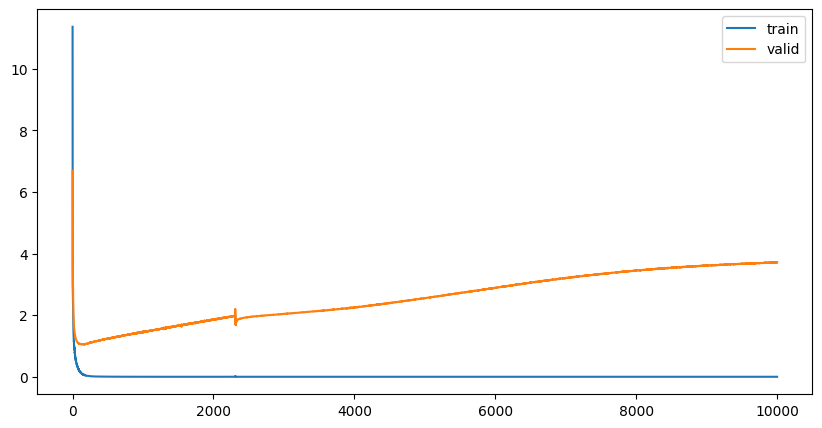

In [123]:
from typing import Generator
import jax
import optax
import jax.numpy as jnp
import flax
import tqdm
from functools import partial

@flax.struct.dataclass
class Network:
    layers: tuple[tuple[jax.Array, jax.Array]]


def forward(x: jax.Array, network: Network) -> jax.Array:
    
    h = x
    for w, b in network.layers[:-1]:
        h = h @ w.T + b 
        h = jax.nn.relu(h)
    
    w, b = network.layers[-1]
    logits = h @ w.T + b 
    return logits


def loss(
    network: Network,
    x: jax.Array,
    y: jax.Array,
):
    yhat = forward(x, network)
    return optax.sigmoid_binary_cross_entropy(yhat, y).mean()

def train_step(
    x: jax.Array,
    y: jax.Array,
    network: Network,
    opt_state: jax.Array,
    optimizer: optax.GradientTransformationExtraArgs
) -> tuple[jax.Array, Network, jax.Array]:

    l, grad = jax.value_and_grad(loss)(network, x, y)
    updates, opt_state = optimizer.update(grad, opt_state, network)
    network = optax.apply_updates(network, updates)

    return l, network, opt_state
    
@jax.jit
def valid_step(
    x: jax.Array,
    y: jax.Array,
    network: Network,
) -> tuple[jax.Array, Network, jax.Array]:
    l = loss(network, x, y)
    return l


def init_mlp(layers: list[int], key: jax.Array) -> tuple[tuple[jax.Array, jax.Array]]:

    arch = []

    initializer = jax.nn.initializers.he_normal()
    keys = jax.random.split(key, len(layers) - 1)
    
    for prev, fol, k in zip(layers[:-1], layers[1:], keys, strict=True):

        wkey, bkey = jax.random.split(k, 2)

        w = initializer(wkey, (fol, prev))
        b = jax.random.normal(bkey, shape=(fol,)) * (1e-3)

        arch.append((w, b))

    return tuple(arch)


def batch_dataset(x: np.ndarray, y: np.ndarray, batch: int, shuffle: bool = False) -> Generator[tuple[np.ndarray, np.ndarray], None, None]:
    
    n = x.shape[0]

    if shuffle:
        si = np.random.permutation(n)
        x = x[si, :]
        y = y[si, :]

    n_batches = int(np.ceil(n / batch)) 
    for i_batch in range(n_batches):

        s = i_batch * batch
        e = s + batch

        yield x[s:e, :], y[s:e, :]


def train(
    x: np.ndarray,
    y: np.ndarray,
    epochs: int,
    valid_p: float = 0.1,
    batch_size: int = 128,
):
    

    key = jax.random.key(seed=0)
    kinit, kloop, kvalid, k4, k5, key = jax.random.split(key, 6)
    
    perm = np.random.permutation(x.shape[0])
    train_size = int((1 - valid_p) * x.shape[0])
    train_idx, valid_idx = perm[:train_size], perm[train_size:]
    x_train, y_train = x[train_idx], y[train_idx]
    x_valid, y_valid = x[valid_idx], y[valid_idx]

    
    network = Network(init_mlp(
        layers=[1_536, 256, 256, 256, 10],
        key=kinit
    ))

    optimizer = optax.adamw(1e-4, weight_decay=1e-3)
    opt_state = optimizer.init(network)

    train_step_compiled = jax.jit(partial(train_step, optimizer=optimizer))

    tl = []
    vl = []
    for _ in tqdm.tqdm(range(epochs)):

        k_use_loop, kloop = jax.random.split(kloop, 2) 

        bl = []
        for x_batch, y_batch in batch_dataset(x_train, y_train, batch=batch_size, shuffle=True):
            x_batch = jax.device_put(x_batch)
            y_batch = jax.device_put(y_batch)

            l, network, opt_state = train_step_compiled(x_batch, y_batch, network, opt_state)
            bl.append(l.mean().item())

        

        tl.append(np.mean(bl))
        
        bl = []
        for x_batch, y_batch in batch_dataset(x_valid, y_valid, batch=batch_size):

            x_batch = jax.device_put(x_batch)
            y_batch = jax.device_put(y_batch)

            l = valid_step(x_batch, y_batch, network)

            bl.append(l.mean().item())
        vl.append(np.mean(bl))
    
    return tl, vl


tl, vl = train(x, y, epochs=10_000, batch_size=512)

from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(tl, label="train")
ax.plot(vl, label="valid")

ax.legend()
plt.show()
    

In [7]:
import jax
import jax.numpy as jnp

layers = [(jnp.zeros((10, 10)),  jnp.ones(10)), (jnp.ones((5, 5)),)]

# Flatten tree into leaves and treedef
leaves, treedef = jax.tree.flatten(layers)

# Convert each leaf to list (for e.g. JSON compatibility)
pa_leaves = [x.tolist() for x in leaves]

# Rebuild the tree of Python lists
pa = jax.tree.unflatten(treedef, pa_leaves)

# Convert back to JAX arrays, restoring dtype from original leaves
l = jax.tree.unflatten(treedef, [jnp.array(x, dtype=orig.dtype)
                                 for x, orig in zip(pa_leaves, leaves)])
l

[(Array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
  Array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=float32)),
 (Array([[1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.]], dtype=float32),)]

In [10]:
jnp.array([2]).mean()

Array(2., dtype=float32)

In [11]:
jax.devices('cpu')

[CpuDevice(id=0)]